In [1]:
from collections.abc import Callable, Sequence
from functools import reduce
from operator import mul
from pathlib import Path
from typing import Literal

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from context_flux_no.nn import PatchEmbedding, TransformerEncoderBlock
from context_flux_no.nn.misc import to_complex_dtype, to_ntuple
from context_flux_no.training import PDEDataset, RandomMiniBatching, SegmentLoader
from einops import rearrange
from equinox._misc import default_floating_dtype
from jaxtyping import Array, Complex, Float, Int, PRNGKeyArray


jax.config.update("jax_enable_x64", True)

In [2]:
class SineCosinePosEncoding2D_(eqx.Module):
    """2D sine-cosine embedding implementation from Taeyoung's code.

    Difference between this and nn.SineCosinePosEncoding2D is that this
    implementation sums the x and y embeddings, whereas the SimpleViT implemention
    uses concatenation.
    """

    encoding_dim: int = eqx.field(static=True)
    temperature: float = eqx.field(static=True)

    def __init__(self, encoding_dim: int, temperature: float = 10000.0):
        if encoding_dim % 2 != 0:
            raise ValueError("Encoding dimension must be a multiple of 2.")
        self.encoding_dim = encoding_dim
        self.temperature = temperature

    def __call__(self, row: int, col: int) -> Float[Array, "row col encoding_dim"]:
        y, x = jnp.mgrid[:row], jnp.mgrid[:col]
        k = 1 / jnp.logspace(0.0, 1.0, self.encoding_dim // 2, base=self.temperature)

        kx: Float[Array, "col encoding_dim//2"] = jnp.einsum("...,d->...d", x, k)
        ky: Float[Array, "row encoding_dim//2"] = jnp.einsum("...,d->...d", y, k)

        pos_embed_x = jnp.concatenate([jnp.sin(kx), jnp.cos(kx)], axis=-1)
        pos_embed_y = jnp.concatenate([jnp.sin(ky), jnp.cos(ky)], axis=-1)
        return rearrange(pos_embed_y, "row embed -> row 1 embed") + pos_embed_x

In [3]:
class ViTContextModule(eqx.Module):
    patch_embedding: PatchEmbedding
    positional_encoding: SineCosinePosEncoding2D_
    cls_token: Float[Array, "1 embedding_dim"]
    encoder_blocks: list[TransformerEncoderBlock]
    layernorm: eqx.nn.LayerNorm
    num_layers: int = eqx.field(static=True)
    embedding_dim: int = eqx.field(static=True)

    def __init__(
        self,
        patch_size: tuple[int, int],
        in_channels: int,
        embedding_dim: int,
        hidden_dim: int,
        num_heads: int,
        num_layers: int,
        dropout: float,
        *,
        key: PRNGKeyArray,
    ):
        keys = jax.random.split(key, num_layers + 2)
        self.patch_embedding = PatchEmbedding(
            patch_size,
            in_channels,
            embedding_dim,
            flat_patch_positions=False,
            key=keys[0],
        )
        self.positional_encoding = SineCosinePosEncoding2D_(embedding_dim)
        self.cls_token = jax.random.truncated_normal(
            keys[1], lower=-2, upper=2, shape=(1, embedding_dim)
        )
        self.encoder_blocks = [
            TransformerEncoderBlock(
                num_heads, embedding_dim, hidden_dim, dropout, key=keys[i + 2]
            )
            for i in range(num_layers)
        ]
        self.layernorm = eqx.nn.LayerNorm(embedding_dim)

        self.num_layers = num_layers
        self.embedding_dim = embedding_dim

    def __call__(
        self, x: Float[Array, "height width channels"], *, key: PRNGKeyArray
    ) -> tuple[
        Float[Array, " embedding_dim"],
        Float[Array, "patches_row patches_col embedding_dim"],
    ]:
        x_embed: Float[Array, "patches_row patches_col embedding_dim"] = (
            self.patch_embedding(x)
        )
        ## Note that the order is different from how ViTs are usually implemented
        ## Typically, it is class token first, then positional encoding.
        ## However, this makes class token incompatible with 2d positional encoding,
        ## hence the reversed order as done below
        row, col, _ = x_embed.shape
        x_embed = x_embed + self.positional_encoding(row, col)

        x_embed = rearrange(x_embed, "row col embed -> (row col) embed")
        x_embed: Float[Array, "patches_row*patches_col+1 embedding_dim"] = (
            jnp.concatenate((self.cls_token, x_embed), axis=0)
        )
        keys = jax.random.split(key, self.num_layers)
        for k, encoder_block in zip(keys, self.encoder_blocks):
            x_embed = encoder_block(x_embed, key=k)

        # x_embed[0] is the representative value over the entire image
        # Also return patchwise embeddings as the second argument
        x_embed = jax.vmap(self.layernorm)(x_embed)
        return x_embed[0], rearrange(
            x_embed[1:], "(row col) embed -> row col embed", row=row
        )

In [4]:
class HyperFourier(eqx.Module):
    """Hypernetwork version of the N-dimensional Fourier layer.

    The complex weights for the spectral convolution operation is created
    using a MLP."""

    num_spatial_dims: int
    weight_net: eqx.nn.MLP
    linear_transform: eqx.nn.Conv
    activation: Callable
    in_channels: int = eqx.field(static=True)
    out_channels: int = eqx.field(static=True)
    frequency_modes: tuple[int, ...] = eqx.field(static=True)
    fourier_weight_shape: tuple[int, ...] = eqx.field(static=True)
    hyper_in_dims: int = eqx.field(static=True)
    hyper_width: int = eqx.field(static=True)
    hyper_depth: int = eqx.field(static=True)

    def __init__(
        self,
        num_spatial_dims: int,
        in_channels: int,
        out_channels: int,
        frequency_modes: int | Sequence[int],
        hyper_in_dims: int,
        hyper_depth: int,
        hyper_width: int,
        activation: Callable = jax.nn.gelu,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        r"""
        **Arguments**

        - `num_spatial_dims`: Number of spatial dimensions.
        - `in_channels`: Number of channels (dimensions) of the input functions. The
            input to the layer should be a vector of shape `(in_channels, grids)`,
            where `grids` is the number of equi-spaced grid points the function was
            sampled on.
        - `out_channels`: Number of channels (dimensions) of the output functions. The
            output from the layer will be a vector of shape `(out_channels, grids)`.
        - `frequency_modes`: Number of frequency modes per dimensoin that will be used
            in the layer.
            For an equi-spaced grid of $n$(=`grids`) points and width $L$, this
            corresponds to using $\lambda_j=j/2L, j=0, 1, \dots frequency_modes$
            spatial frequency values.
        - `dtype`: The dtype to use for the weight and the bias in this layer.
            Defaults to either `jax.numpy.float32` or `jax.numpy.float64` depending
            on whether JAX is in 64-bit mode.
        - `key`: A `jax.random.PRNGKey` used to provide randomness for parameter
            initialization. (Keyword only argument.)
        """
        frequency_modes = to_ntuple(frequency_modes, num_spatial_dims)
        dtype = default_floating_dtype() if dtype is None else dtype
        wkey, lkey = jax.random.split(key, 2)

        self.fourier_weight_shape = (
            out_channels,
            in_channels,
            *[2 * i for i in frequency_modes[:-1]],
            frequency_modes[-1],
        )
        self.weight_net = eqx.nn.MLP(
            in_size=hyper_in_dims,
            out_size=reduce(mul, self.fourier_weight_shape),
            width_size=hyper_width,
            depth=hyper_depth,
            activation=activation,
            dtype=to_complex_dtype(dtype),
            key=wkey,
        )

        self.linear_transform = eqx.nn.Conv(
            num_spatial_dims, in_channels, out_channels, 1, key=lkey
        )

        self.num_spatial_dims = num_spatial_dims
        self.activation = activation
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.frequency_modes = frequency_modes
        self.hyper_in_dims = hyper_in_dims
        self.hyper_width = hyper_width
        self.hyper_depth = hyper_depth

    def spectral_conv(
        self,
        v: Float[Array, " in_channels *grids"],
        fourier_weights: Float[Array, " {*self.fourier_weight_shape} *grids"],
    ) -> Float[Array, " out_channels *grids"]:
        """**Arguments**

        - `v`: The input, corresponding to 1D function values sampled from a equi-spaced
            grid. Should be a JAX array of shape `(in_channels, *grids)`.
            `grids` corresponds to an N-tuple of integers corresponding to the number of
            grid points per spatial dimension. Thus `len(grids)=self.num_spatial_dims`.

        For each frequency of the frequency_modes used in the layer, the spectral
        component corresponding to each input channel is linearly mixed to produce the
        spectral components of the output channels.
        """
        n_grids = v.shape[1:]
        v_fft: Complex[Array, "in_channels grids"] = jnp.fft.rfftn(v, axes=(-1,))
        v_fft_trunc = v_fft[:, *self.frequency_mask(n_grids)]
        out_fft_trunc: Complex[Array, "out_channels frequency_modes"] = jnp.einsum(
            "ij...,j...->i...",
            fourier_weights,
            v_fft_trunc,
        )
        out_fft = jnp.zeros_like(
            v_fft, shape=(self.out_channels, *n_grids[:-1], n_grids[-1] // 2 + 1)
        )
        out_fft = out_fft.at[:, *self.frequency_mask(n_grids)].set(out_fft_trunc)
        out = jnp.fft.irfftn(out_fft, s=n_grids)
        return out

    def frequency_mask(
        self, grid_shape: tuple[int, ...]
    ) -> tuple[Int[Array, "..."], ...]:
        *n_grids, _ = grid_shape
        *n_modes, n_mode_last = self.frequency_modes
        return jnp.ix_(
            *[jnp.r_[:m, g - m : g] for (g, m) in zip(n_grids, n_modes)],
            jnp.r_[0:n_mode_last],
        )

    def __call__(
        self,
        v: Float[Array, "in_channels grids"],
        hyper_input: Float[Array, " hyper_in_dim"],
        *,
        key: PRNGKeyArray | None = None,
    ) -> Float[Array, "out_channels grids"]:
        """**Arguments**

        - `v`: The input, corresponding to 1D function values sampled from a equi-spaced
            grid. Should be a JAX array of shape `(in_channels, grids)`.
        - `key`: Ignored; provided for compatibility with the rest of the Equinox API.
            (Keyword only argument.)

        For each frequency of the frequency_modes used in the layer, the spectal
        component corresponding to each input channel is linearly mixed to produce the
        spectral components of the output channels.
        """
        fourier_weights = jnp.reshape(
            self.weight_net(hyper_input), self.fourier_weight_shape
        )
        v_out = self.spectral_conv(v, fourier_weights) + self.linear_transform(v)
        return self.activation(v_out)


In [ ]:
class ViTContextHyperFluxFNO(eqx.Module):
    context_module: ViTContextModule
    lift_layer: eqx.nn.MLP
    hyperfourier_layers: list[HyperFourier]
    project_layer: eqx.nn.MLP
    film_net: eqx.nn.Linear

    lift_dim: int = eqx.field(static=True)
    context_embed_dim: int = eqx.field(static=True)
    stencil_size: tuple[int, int] = eqx.field(static=True)
    boundary_condition: Literal["periodic"] = eqx.field(static=True)
    stack_grid: bool = eqx.field(static=True)

    def __init__(
        self,
        data_dim: int,
        depth: int,
        frequency_modes: int,
        lift_dim: int,
        context_embed_dim: int,
        stencil_size: int | tuple[int, int],
        boundary_condition: Literal["periodic"] = "periodic",
        patch_size: tuple[int, int] = (4, 16),
        width_lift: int = 128,
        width_project: int = 128,
        width_vit: int = 128,
        width_hyper: int = 128,
        depth_lift: int = 1,
        depth_project: int = 1,
        depth_vit: int = 4,
        depth_hyper: int = 1,
        vit_heads: int = 4,
        dropout: float = 0.0,
        activation: Callable = jax.nn.gelu,
        stack_grid: bool = True,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        self.stencil_size = (
            (stencil_size, stencil_size)
            if isinstance(stencil_size, int)
            else stencil_size
        )
        self.boundary_condition = boundary_condition

        keys = jax.random.split(key, 4 + depth)

        input_dim = data_dim * (self.stencil_size[0] + self.stencil_size[1] + 1)
        self.lift_layer = eqx.nn.MLP(
            input_dim + 1 if stack_grid else input_dim,
            lift_dim,
            width_lift,
            depth_lift,
            activation,
            dtype=dtype,
            key=keys[0],
        )

        self.context_module = ViTContextModule(
            patch_size=patch_size,
            in_channels=data_dim,
            embedding_dim=context_embed_dim,
            hidden_dim=width_vit,
            num_heads=vit_heads,
            num_layers=depth_vit,
            dropout=dropout,
            key=keys[1],
        )
        self.hyperfourier_layers = [
            HyperFourier(
                num_spatial_dims=1,
                in_channels=lift_dim,
                out_channels=lift_dim,
                frequency_modes=frequency_modes,
                hyper_in_dims=context_embed_dim,
                hyper_width=width_hyper,
                hyper_depth=depth_hyper,
                activation=activation,
                dtype=dtype,
                key=k,
            )
            for k in keys[2 : 2 + depth]
        ]

        self.project_layer = eqx.nn.MLP(
            lift_dim,
            data_dim,
            width_project,
            depth_project,
            activation,
            dtype=dtype,
            key=keys[-2],
        )

        self.film_net = eqx.nn.Linear(context_embed_dim, 2 * lift_dim, key=keys[-1])

        self.stack_grid = stack_grid
        self.lift_dim = lift_dim
        self.context_embed_dim = context_embed_dim

    def create_stencil_axis(
        self, v: Float[Array, "dim x"]
    ) -> Float[Array, "data_dim {self.stencil_size[0]}+{self.stencil_size[1]}+2 grids"]:
        assert self.boundary_condition == "periodic", (
            "Other types of boundary conditions are not supported."
        )
        p, q = self.stencil_size
        v_padded: Float[Array, "in_channels grids+p+q+2"] = jnp.concatenate(
            [v[:, -p - 1 :], v, v[:, 0:q]], axis=1
        )
        return jnp.stack(
            [
                jax.lax.dynamic_slice_in_dim(v_padded, i, p + q + 2, axis=-1)
                for i in range(v.shape[1])
            ],
            axis=-1,
        )

    def flux_model(
        self,
        v_stencil: Float[Array, "dim_stencil x"],
        context_vec: Float[Array, " embedding_dim"],
        film_weights: Float[Array, "2*lift_dim x"],
    ):
        """
        dim_stencil = dim*(self.stencil_size[0]+self.stencil_size[1]+1)
        """
        if self.stack_grid:
            grid = jnp.expand_dims(jnp.linspace(0, 1, v_stencil.shape[-1]), axis=0)
            v_stencil = jnp.concatenate((v_stencil, grid), axis=0)

        gamma, beta = film_weights[: self.lift_dim], film_weights[self.lift_dim :]

        v: Float[Array, "lift_dim x"] = eqx.filter_vmap(
            self.lift_layer, in_axes=-1, out_axes=-1
        )(v_stencil)

        for hyperfourier in self.hyperfourier_layers:
            v = v + gamma * hyperfourier(v, context_vec) + beta

        v = eqx.filter_vmap(self.project_layer, in_axes=-1, out_axes=-1)(v)
        return v

    def __call__(
        self,
        context: Float[Array, "time dim x"],
        v: Float[Array, "dim x"],
        dt: float,
        dx: float,
        *,
        key: jax.random.PRNGKey,
    ):
        context_embed, context_patches = self.context_module(
            rearrange(context, "t d x -> t x d"), key=key
        )

        context_patches_x: Float[Array, "patches_x embedding_dim"] = jnp.mean(
            context_patches, axis=0
        )
        film_weights: Float[Array, "2*lift_dim patches_x"] = jax.vmap(
            self.film_net, in_axes=0, out_axes=1
        )(context_patches_x)

        film_weights: Float[Array, "2*lift_dim x"] = jax.image.resize(
            film_weights, (film_weights.shape[0], v.shape[1]), method="nearest"
        )

        v_stencil: Float[
            Array, "dim {self.stencil_size[0]}+{self.stencil_size[1]}+2 x"
        ] = self.create_stencil_axis(v)

        v_l = rearrange(v_stencil[:, :-1], "dim stencil x -> (dim stencil) x")
        v_r = rearrange(v_stencil[:, 1:], "dim stencil x -> (dim stencil) x")

        f_l = self.flux_model(v_l, context_embed, film_weights)
        f_r = self.flux_model(v_r, context_embed, film_weights)
        return v + dt * (f_l - f_r) / dx

## Import data and run the model

In [14]:
jax.config.update("jax_enable_x64", True)

datadir = Path("./data")
dataset_xr = xr.load_dataset(datadir / "cubic_no_source_train.hdf5")
dataset_xr

<xarray.Dataset> Size: 21MB
Dimensions:  (x: 256, t: 101, sample: 100, dim: 1, param: 3)
Coordinates:
  * x        (x) float64 2kB -0.9961 -0.9883 -0.9805 ... 0.9805 0.9883 0.9961
  * t        (t) float64 808B 0.0 0.001 0.002 0.003 ... 0.097 0.098 0.099 0.1
  * param    (param) object 24B 'a' 'b' 'c'
  * dim      (dim) object 8B 'u'
Dimensions without coordinates: sample
Data variables:
    values   (sample, t, dim, x) float64 21MB 0.7198 0.3809 ... -0.1633
    coeffs   (sample, param) float64 2kB -0.4814 -0.2967 ... -0.1377 0.806

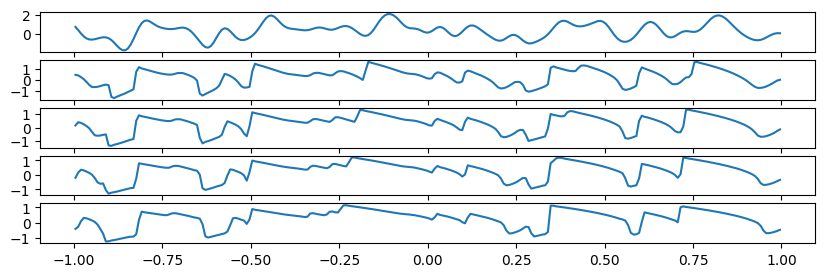

In [15]:
dataset = PDEDataset.from_xarray(dataset_xr)

fig, axes = plt.subplots(5, 1, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.plot(dataset.x, dataset.u[0, i * 20, 0])

In [16]:
loader = SegmentLoader(dataset, 50, RandomMiniBatching(64))
loader_state = loader.init()
batch, loader_state = loader.load_batch(loader_state)

In [17]:
u, t, x, _ = batch
print(u.shape, t.shape, x.shape)

(64, 50, 1, 256) (64, 50) (64, 256)


In [18]:
model = ViTContextHyperFluxFNO(
    data_dim=1,
    depth=4,
    frequency_modes=16,
    lift_dim=96,
    context_embed_dim=96,
    stencil_size=(2, 1),
    key=jax.random.key(0),
)

In [25]:
dt, dx = t[0, 1] - t[0, 0], x[0, 1] - x[0, 0]
context = u[
    0,
    :10,
]
u_t = u[0, 20]

u_t1_pred = model(context, u_t, dt, dx, key=jax.random.key(0))

(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)


In [29]:
n_iter = 40

u_pred = u_t
for _ in range(n_iter):
    u_pred = model(context, u_pred, dt, dx, key=jax.random.key(0))


(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)
(96, 256)
(96, 256)
(192, 256)
(96, 256)
(96, 256)


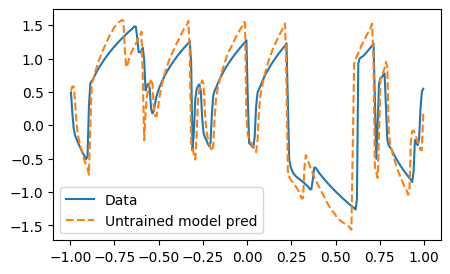

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x[0], u[0, 20 + 40][0], label="Data")
ax.plot(x[0], u_t1_pred[0], "--", label="Untrained model pred")
ax.legend()